In [2]:
import numpy as np
from matplotlib import pyplot as plt
import math

In [3]:
def pdf(x):

    y=np.zeros(len(x))

    pi=np.pi
    for i in range(0,len(y)):
        if 0 <= x[i] and x[i] <= pi:
            y[i] = 0.5*np.sin(x[i])
        else:
            y[i] = 0

    return y

def cdf(x):

    y=np.zeros(len(x))

    pi=np.pi
    for i in range(0,len(y)):
        if x[i] < 0:
            y[i] = 0
        elif x[i] > pi:
            y[i] = 1
        else:
            cos = np.cos(x[i])
            y[i] = 0.5*(1-cos)

    return y

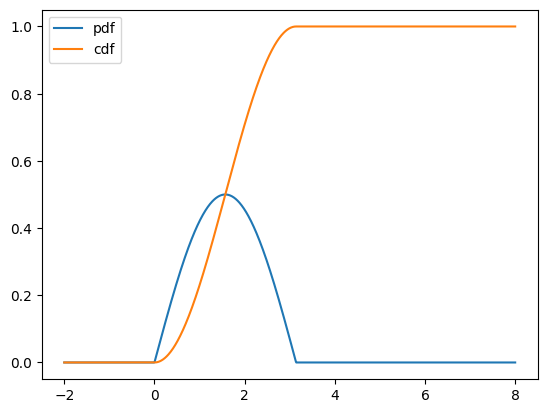

In [4]:
x = np.linspace(-2,8,1000)

p_x = pdf(x)
f_x = cdf(x)

plt.plot(x, p_x, label='pdf')
plt.plot(x,f_x, label='cdf')
plt.legend()
plt.show()

In [5]:
def inverse_cdf(x):
    u = np.asarray(x, dtype=float)
    if np.any((u < 0) | (1 < u)):
        raise ValueError("u outside domain [0, 1]")
    return np.arccos(1 - 2*u)

In [6]:
u = np.random.rand(100000,)

q_u=inverse_cdf(u)
#q_u = np.asarray(q_u).flatten()  # or .ravel(), or q_u[0]
print(q_u.shape)  # should now be (1000,)

(100000,)


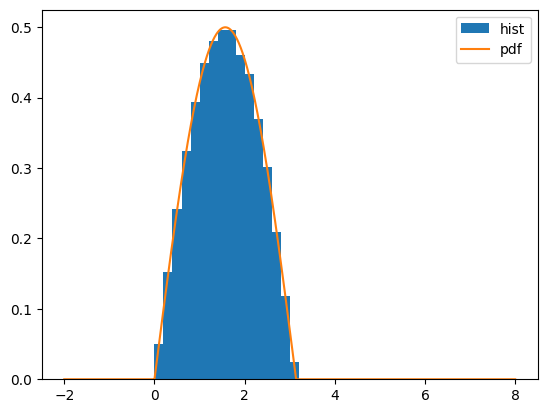

In [7]:
plt.hist(q_u, bins=30, density = True, label='hist', range=(-2,4))
plt.plot(x, p_x, label='pdf')
plt.legend()
plt.show()

In [8]:
def poisson_distr(lam, n):
    y = np.zeros(n)
    for i in range(0,n):
        y[i] = lam**i/math.factorial(i) * np.exp(-lam)
    return y

def poisson_simul(n,dx):
    y = np.zeros(n)
    for i in range(0,n):
        x = np.random.rand(i,)
        for j in range(0,i):
            if x[j] <= dx:
                y[i] += 1
    return y

In [10]:
n = 1000
dx=0.01
lam = n*dx

x = np.linspace(0,n,n)

#p = poisson_distr(lam,n)
#s=poisson_simul(n,dx)

#plt.plot(x,p, label='poisson distribution')
#plt.plot(x,s,label='simulation')
#plt.legend()
#plt.show()

Text(0, 0.5, '$\\Pr(K=k)$')

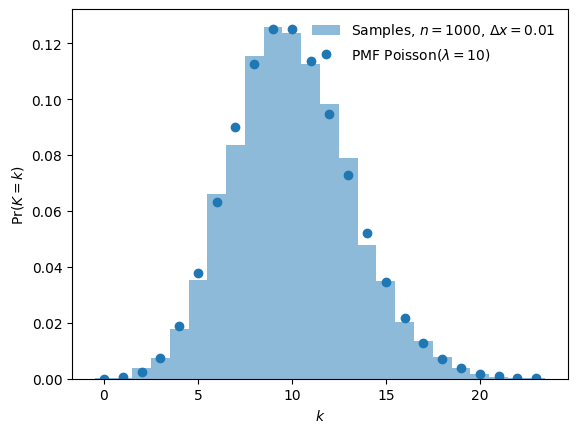

In [13]:
import scipy
rng = np.random.default_rng(42)
n_repeat=10000
x = rng.uniform(size=(n_repeat, n))
counts = np.sum(x < dx, axis=1)

k = np.arange(24)
plt.hist(counts, bins=np.arange(25)-0.5, density=True, alpha=0.5,
         label=rf"Samples, $n={n}$, $\Delta x={dx}$")
plt.plot(k, scipy.stats.poisson(lam).pmf(k), "o", c="C0", label=rf"PMF $\mathrm{{Poisson}}(\lambda={lam:g})$")
plt.legend(frameon=False)
plt.xlabel("$k$")
plt.ylabel(r"$\Pr(K=k)$")